# 10 파이썬 성능 개선

## 10.1 반복문

### 10.1.1 파이썬

In [1]:
import random

In [2]:
def average_py(n):
    s = 0
    for i in range(n):
        s += random.random()
    return s / n

In [3]:
n = 10000000

In [4]:
%time average_py(n)

CPU times: user 186 ms, sys: 2.15 ms, total: 188 ms
Wall time: 190 ms


0.5000621358712989

In [5]:
%timeit average_py(n)

178 ms ± 4.23 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [6]:
%time sum([random.random() for _ in range(n)]) / n

CPU times: user 228 ms, sys: 23.1 ms, total: 251 ms
Wall time: 251 ms


0.49993772951532667

### 10.1.2 NumPy

In [7]:
import numpy as np

In [8]:
def average_np(n):
    s = np.random.random(n)
    return s.mean()

In [9]:
%time average_np(n)

CPU times: user 70.9 ms, sys: 669 ms, total: 739 ms
Wall time: 42.7 ms


np.float64(0.5000511411482824)

In [10]:
%timeit average_np(n)

20.4 ms ± 422 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [11]:
s = np.random.random(n)
s.nbytes

80000000

### 10.1.3 Numba

In [12]:
import numba

In [13]:
average_nb = numba.jit(average_py)

In [14]:
%time average_nb(n)

CPU times: user 159 ms, sys: 33.4 ms, total: 192 ms
Wall time: 249 ms


0.4998571791103755

In [15]:
%time average_nb(n)

CPU times: user 24.4 ms, sys: 154 μs, total: 24.6 ms
Wall time: 24.6 ms


0.5001349732117427

In [16]:
%timeit average_nb(n)

23.9 ms ± 56.3 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


### 10.1.4 Cython

In [17]:
%load_ext Cython

In [18]:
%%cython -a
import random
def average_cy1(int n):
    cdef int i
    cdef float s = 0
    for i in range(n):
        s += random.random()
    return s / n

Content of stderr:
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored

In [19]:
%time average_cy1(n)

CPU times: user 268 ms, sys: 1.15 ms, total: 269 ms
Wall time: 269 ms


0.5001152753829956

In [20]:
%timeit average_cy1(n)

256 ms ± 7.82 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [21]:
%%cython
from libc.stdlib cimport rand
cdef extern from 'limits.h':
    int INT_MAX
cdef int i
cdef float rn
for i in range(5):
    rn = rand() / INT_MAX
    print(rn)

Content of stderr:
/Users/kunyoungkim/.ipython/cython/_cython_magic_ff82ebf859165d37cd8630655926a655dbf64aa8606f0efa1ccbd67d32afd1c4.c:2347:7: warning: code will never be executed [-Wunreachable-code]
 2347 |       PyErr_SetString(PyExc_ZeroDivisionError, "float division");
      |       ^~~~~~~~~~~~~~~
1 warning generated.
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored0.3835020661354065
0.5194163918495178
0.8309653401374817
0.03457210958003998
0.05346163362264633


In [22]:
%%cython -a
from libc.stdlib cimport rand
cdef extern from 'limits.h':
    int INT_MAX
def average_cy2(int n):
    cdef int i
    cdef float s = 0
    for i in range(n):
        s += rand() / INT_MAX
    return s / n

Content of stderr:
/Users/kunyoungkim/.ipython/cython/_cython_magic_1b932e9c3509eccc3e118d59c1d50c0419c374f6e332f8473abde3003f309f01.c:2497:7: warning: code will never be executed [-Wunreachable-code]
 2497 |       PyErr_SetString(PyExc_ZeroDivisionError, "float division");
      |       ^~~~~~~~~~~~~~~
1 warning generated.
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored

In [23]:
%time average_cy2(n)

CPU times: user 47.2 ms, sys: 316 μs, total: 47.5 ms
Wall time: 47.4 ms


0.500017523765564

In [24]:
%timeit average_cy2(n)

35.6 ms ± 62.4 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## 10.2 알고리즘

## 10.2.1 소수 확인

**파이썬**

In [25]:
def is_prime(I):
    if I % 2 == 0: return False
    for i in range(3, int(I ** 0.5) + 1, 2):
        if I % i == 0: return False
    return True

In [26]:
n = int(1e8 + 3)
n

100000003

In [27]:
%time is_prime(n)

CPU times: user 10 μs, sys: 0 ns, total: 10 μs
Wall time: 11 μs


False

In [28]:
p1 = int(1e8 + 7)
p1

100000007

In [29]:
%time is_prime(p1)

CPU times: user 96 μs, sys: 14 μs, total: 110 μs
Wall time: 139 μs


True

In [30]:
p2 = 100109100129162907

In [31]:
p2.bit_length()

57

In [32]:
%time is_prime(p2)

CPU times: user 2.26 s, sys: 13.3 ms, total: 2.27 s
Wall time: 2.27 s


True

**Numba**

In [33]:
is_prime_nb = numba.jit(is_prime)

In [34]:
%time is_prime_nb(n)

CPU times: user 22.5 ms, sys: 2.79 ms, total: 25.2 ms
Wall time: 24.9 ms


False

In [35]:
%time is_prime_nb(n)

CPU times: user 5 μs, sys: 0 ns, total: 5 μs
Wall time: 6.2 μs


False

In [36]:
%time is_prime_nb(p1)

CPU times: user 6 μs, sys: 1 μs, total: 7 μs
Wall time: 6.91 μs


True

In [37]:
%time is_prime_nb(p2)

CPU times: user 74.6 ms, sys: 536 μs, total: 75.1 ms
Wall time: 75.1 ms


True

**Cython**

In [38]:
%%cython
def is_prime_cy1(I):
    if I % 2 == 0: return False
    for i in range(3, int(I ** 0.5) + 1, 2):
        return False
    return True

Content of stderr:
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored

In [39]:
%timeit is_prime(p1)

71.1 μs ± 103 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [40]:
%timeit is_prime_cy1(p1)

58.3 ns ± 0.49 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [41]:
%%cython
def is_prime_cy2(long I):
    cdef long i
    if I % 2 == 0: return False
    for i in range(3, int(I ** 0.5) + 1, 2):
        if I % i == 0: return False
    return True

Content of stderr:
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored

In [42]:
%timeit is_prime_cy2(p1)

2.91 μs ± 10.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [43]:
%timeit is_prime_nb(p2)

80.5 ms ± 2.87 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [44]:
%timeit is_prime_cy2(p2)

92.2 ms ± 448 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


**멀티프로세싱**

In [45]:
import multiprocessing as mp

In [46]:
%%time
with mp.get_context('fork').Pool(processes=4) as pool:
    result = pool.map(is_prime, 10 * [p1])
result

CPU times: user 4.77 ms, sys: 11.1 ms, total: 15.8 ms
Wall time: 19.8 ms


[True, True, True, True, True, True, True, True, True, True]

In [47]:
%%time
with mp.get_context('fork').Pool(processes=4) as pool:
    result = pool.map(is_prime_nb, 10 * [p2])
result

CPU times: user 3.56 ms, sys: 14.8 ms, total: 18.4 ms
Wall time: 287 ms


[True, True, True, True, True, True, True, True, True, True]

In [48]:
%%time
with mp.get_context('fork').Pool(processes=4) as pool:
    result = pool.map(is_prime_cy2, 10 * [p2])
result

CPU times: user 1.82 ms, sys: 9.38 ms, total: 11.2 ms
Wall time: 303 ms


[True, True, True, True, True, True, True, True, True, True]

### 10.2.2 피보나치 수

**재귀 알고리즘**

In [49]:
def fib_rec_py1(n):
    if n < 2:
        return n
    else:
        return fib_rec_py1(n - 1) + fib_rec_py1(n - 2)

In [50]:
%time fib_rec_py1(35)

CPU times: user 361 ms, sys: 2.46 ms, total: 363 ms
Wall time: 363 ms


9227465

In [51]:
@numba.jit
def fib_rec_nb(n):
    if n < 2:
        return n
    else:
        return fib_rec_nb(n - 1) + fib_rec_nb(n - 2)

In [52]:
%time fib_rec_nb(35)

CPU times: user 38.7 ms, sys: 2.47 ms, total: 41.2 ms
Wall time: 40.9 ms


9227465

In [53]:
%time fib_rec_nb(35)

CPU times: user 23.3 ms, sys: 166 μs, total: 23.4 ms
Wall time: 23.4 ms


9227465

In [54]:
%%cython
def fib_rec_cy(int n):
    if n < 2:
        return n
    else:
        return fib_rec_cy(n - 1) + fib_rec_cy(n - 2)

Content of stderr:
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored

In [55]:
%time fib_rec_cy(35)

CPU times: user 302 ms, sys: 2.51 ms, total: 305 ms
Wall time: 306 ms


9227465

In [56]:
from functools import lru_cache as cache

In [57]:
@cache(maxsize=None)
def fib_rec_py2(n):
    if n < 2:
        return n
    else:
        return fib_rec_py2(n - 1) + fib_rec_py2(n - 2)

In [58]:
%time fib_rec_py2(35)

CPU times: user 10 μs, sys: 3 μs, total: 13 μs
Wall time: 15 μs


9227465

In [59]:
%time fib_rec_py2(80)

CPU times: user 15 μs, sys: 1e+03 ns, total: 16 μs
Wall time: 16 μs


23416728348467685

**반복 알고리즘**

In [60]:
def fib_it_py(n):
    x, y = 0, 1
    for i in range(1, n + 1):
        x, y = y, x + y
    return x

In [61]:
%time fib_it_py(80)

CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 5.01 μs


23416728348467685

In [62]:
fib_it_nb = numba.jit(fib_it_py)

In [63]:
%time fib_it_nb(80)

CPU times: user 16.2 ms, sys: 2.6 ms, total: 18.8 ms
Wall time: 18.6 ms


23416728348467685

In [64]:
%%cython
def fib_it_cy1(int n):
    cdef long i
    cdef long x = 0, y = 1
    for i in range(1, n + 1):
        x, y = y, x + y
    return x

Content of stderr:
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored

In [65]:
%time fib_it_cy1(80)

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 3.1 μs


23416728348467685

In [66]:
%%time
fn = fib_rec_py2(150)
print(fn)

9969216677189303386214405760200
CPU times: user 47 μs, sys: 23 μs, total: 70 μs
Wall time: 68.2 μs


In [67]:
fn.bit_length()

103

In [68]:
%%time
fn = fib_it_nb(150)
print(fn)

6792540214324356296
CPU times: user 81 μs, sys: 31 μs, total: 112 μs
Wall time: 111 μs


In [69]:
fn.bit_length()

63

In [70]:
%%time
fb = fib_it_cy1(150)
print(fn)

6792540214324356296
CPU times: user 33 μs, sys: 7 μs, total: 40 μs
Wall time: 37.2 μs


In [71]:
fn.bit_length()

63

In [72]:
%%cython
cdef extern from *:
    ctypedef int int128 '__int128_t'
def fib_it_cy2(int n):
    cdef int128 i
    cdef int128 x = 0, y = 1
    for i in range(1, n + 1):
        x, y = y, x + y
    return x

Content of stderr:
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored

In [73]:
%%time
fn = fib_it_cy2(150)
print(fn)

9969216677189303386214405760200
CPU times: user 47 μs, sys: 6 μs, total: 53 μs
Wall time: 49.1 μs


In [74]:
fn.bit_length()

103

### 10.2.3 원주율

In [75]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [76]:
rn = [(random.random() * 2 - 1, random.random() * 2 - 1) for _ in range(500)]

In [77]:
rn = np.array(rn)
rn[:5]

array([[ 0.10585085,  0.7840813 ],
       [ 0.68270111,  0.93599062],
       [ 0.23426089, -0.30038615],
       [-0.53666609, -0.01996033],
       [-0.2478558 ,  0.44770854]])

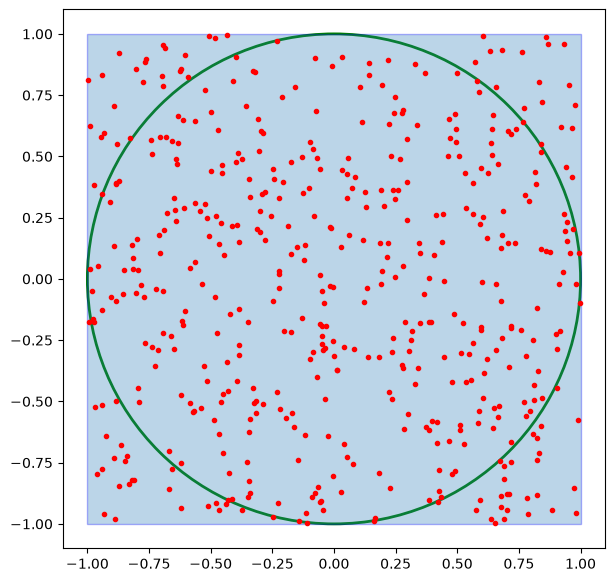

In [78]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(1, 1, 1)

circ = plt.Circle((0, 0), radius=1, edgecolor='g', lw=2.0, facecolor='None')
box = plt.Rectangle((-1, -1), 2, 2, edgecolor='b', alpha=0.3)

ax.add_patch(circ)
ax.add_patch(box)

plt.plot(rn[:,0], rn[:,1], 'r.')
plt.ylim(-1.1, 1.1)
plt.xlim(-1.1, 1.1)
plt.show()

In [79]:
n = int(1e7)

In [80]:
%time rn = np.random.random((n, 2)) * 2 - 1

CPU times: user 45.8 ms, sys: 19 ms, total: 64.8 ms
Wall time: 64.3 ms


In [81]:
rn.nbytes

160000000

In [82]:
%time distance = np.sqrt((rn ** 2).sum(axis=1))

CPU times: user 58.8 ms, sys: 11.7 ms, total: 70.5 ms
Wall time: 69.9 ms


In [83]:
%time frac = (distance <= 1.0).sum() / len(distance)

CPU times: user 3.98 ms, sys: 1.55 ms, total: 5.53 ms
Wall time: 4.92 ms


In [84]:
pi_mcs = frac * 4
pi_mcs

np.float64(3.1416476)

In [85]:
%%time
# total amount of time using Numpy
rn = np.random.random((n,2)) * 2 - 1
distance = np.sqrt((rn ** 2).sum(axis=1))
frac = (distance <= 1).sum() / len(distance)
pi_mcs = frac * 4
pi_mcs

CPU times: user 108 ms, sys: 28.4 ms, total: 136 ms
Wall time: 136 ms


np.float64(3.1420076)

In [86]:
def mcs_pi_py(n):
    circle = 0
    for _ in range(n):
        x, y = random.random(), random.random()
        if (x ** 2 + y ** 2) ** 0.5 <= 1:
            circle += 1
    return (4 * circle) / n

In [87]:
%time mcs_pi_py(n)

CPU times: user 1.03 s, sys: 7.82 ms, total: 1.03 s
Wall time: 1.04 s


3.142214

In [88]:
mcs_pi_nb = numba.jit(mcs_pi_py)

In [89]:
%time mcs_pi_nb(n)

CPU times: user 108 ms, sys: 6.06 ms, total: 114 ms
Wall time: 116 ms


3.1416264

In [90]:
%time mcs_pi_nb(n)

CPU times: user 63.5 ms, sys: 378 μs, total: 63.8 ms
Wall time: 64.3 ms


3.1412236

In [91]:
%%cython -a
import random
def mcs_pi_cy1(int n):
    cdef i, circle = 0
    cdef float x, y
    for i in range(n):
        x, y = random.random(), random.random()
        if (x ** 2 + y ** 2) <= 1:
            circle += 1
    return (4 * circle) / n

Content of stderr:
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored

In [92]:
%time mcs_pi_cy1(n)

CPU times: user 456 ms, sys: 3.92 ms, total: 460 ms
Wall time: 460 ms


3.1415192

In [93]:
%%cython -a
from libc.stdlib cimport rand
cdef extern from 'limits.h':
    int INT_MAX
def mcs_pi_cy2(int n):
    cdef int i, circle = 0
    cdef float x, y
    for i in range(n):
        x, y = rand() / INT_MAX, rand() / INT_MAX
        if (x * x + y * y) <= 1:
            circle += 1
    return circle / n * 4

Content of stderr:
/Users/kunyoungkim/.ipython/cython/_cython_magic_1210cdf426f6f43c58c600a8284562741a61140a5b324a4b93ca52c2deb7ec32.c:2511:7: warning: code will never be executed [-Wunreachable-code]
 2511 |       PyErr_SetString(PyExc_ZeroDivisionError, "float division");
      |       ^~~~~~~~~~~~~~~
/Users/kunyoungkim/.ipython/cython/_cython_magic_1210cdf426f6f43c58c600a8284562741a61140a5b324a4b93ca52c2deb7ec32.c:2505:7: warning: code will never be executed [-Wunreachable-code]
 2505 |       PyErr_SetString(PyExc_ZeroDivisionError, "float division");
      |       ^~~~~~~~~~~~~~~
2 warnings generated.
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored

In [94]:
%time mcs_pi_cy2(n)

CPU times: user 88.9 ms, sys: 639 μs, total: 89.6 ms
Wall time: 89.5 ms


3.1419384

## 10.3 이항트리

### 10.3.1 파이썬

In [95]:
import math

In [96]:
S0 = 36.0
T = 1.0
r = 0.06
sigma = 0.2

In [97]:
def simulate_tree(M):
    dt = T / M
    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u
    S = np.zeros((M + 1, M + 1))
    S[0, 0] = S0
    for t in range(1, M + 1):
        for i in range(t):
            S[i, t] = S[i, t-1] * u
            S[i+1, t] = S[i, t-1] * d
    return S

In [98]:
np.set_printoptions(formatter={'float': lambda x: '%6.2f' % x})

In [99]:
simulate_tree(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [  0.00,  32.57,  36.00,  39.79,  43.97],
       [  0.00,   0.00,  29.47,  32.57,  36.00],
       [  0.00,   0.00,   0.00,  26.67,  29.47],
       [  0.00,   0.00,   0.00,   0.00,  24.13]])

In [100]:
%time simulate_tree(500)

CPU times: user 23.2 ms, sys: 1.19 ms, total: 24.4 ms
Wall time: 24.1 ms


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [  0.00,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [  0.00,   0.00,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501))

### 10.3.2 NumPy

In [101]:
M = 4

In [102]:
up = np.arange(M + 1)
up = np.resize(up, (M + 1, M + 1))
up

array([[0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4]])

In [103]:
down = up.T * 2
down

array([[0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [4, 4, 4, 4, 4],
       [6, 6, 6, 6, 6],
       [8, 8, 8, 8, 8]])

In [104]:
up - down

array([[ 0,  1,  2,  3,  4],
       [-2, -1,  0,  1,  2],
       [-4, -3, -2, -1,  0],
       [-6, -5, -4, -3, -2],
       [-8, -7, -6, -5, -4]])

In [105]:
dt = T / M

In [106]:
S0 * np.exp(sigma * math.sqrt(dt) * (up - down))

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [ 29.47,  32.57,  36.00,  39.79,  43.97],
       [ 24.13,  26.67,  29.47,  32.57,  36.00],
       [ 19.76,  21.84,  24.13,  26.67,  29.47],
       [ 16.18,  17.88,  19.76,  21.84,  24.13]])

In [107]:
 def simulate_tree_np(M):
     dt = T / M
     up = np.arange(M + 1)
     up = np.resize(up, (M + 1, M + 1))
     down = up.transpose() * 2
     S = S0 * np.exp(sigma * math.sqrt(dt) * (up - down))
     return S

In [108]:
simulate_tree_np(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [ 29.47,  32.57,  36.00,  39.79,  43.97],
       [ 24.13,  26.67,  29.47,  32.57,  36.00],
       [ 19.76,  21.84,  24.13,  26.67,  29.47],
       [ 16.18,  17.88,  19.76,  21.84,  24.13]])

In [109]:
%time simulate_tree_np(500)

CPU times: user 1.41 ms, sys: 1.48 ms, total: 2.89 ms
Wall time: 2.66 ms


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [ 35.36,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [ 34.73,  35.05,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.41,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.40,   0.41,   0.41]],
      shape=(501, 501))

### 10.3.3 Numba

In [110]:
simulate_tree_nb = numba.jit(simulate_tree)

In [111]:
simulate_tree_nb(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [  0.00,  32.57,  36.00,  39.79,  43.97],
       [  0.00,   0.00,  29.47,  32.57,  36.00],
       [  0.00,   0.00,   0.00,  26.67,  29.47],
       [  0.00,   0.00,   0.00,   0.00,  24.13]])

In [112]:
%time simulate_tree_nb(500)

CPU times: user 80 μs, sys: 91 μs, total: 171 μs
Wall time: 173 μs


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [  0.00,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [  0.00,   0.00,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501))

In [113]:
%timeit simulate_tree_nb(500)

89.6 μs ± 9.34 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### 10.3.4 Cython

In [114]:
%%cython -a
import numpy as np
from libc.math cimport exp, sqrt
cdef float S0 = 36.0
cdef float T = 1.0
cdef float r = 0.06
cdef float sigma = 0.2
def simulate_tree_cy(int M):
    cdef int t, i
    cdef float dt, u, d
    cdef float[:,:] S = np.zeros((M + 1, M + 1), dtype=np.float32)
    dt = T / M
    u = exp(sigma * sqrt(dt))
    d = 1 / u
    S[0, 0] = S0
    for t in range(1, M + 1):
        for i in range(t):
            S[i, t] = S[i, t-1] * u
            S[i+1, t] = S[i, t-1] * d
    return np.array(S)

Content of stderr:
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored

In [115]:
simulate_tree_cy(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [  0.00,  32.57,  36.00,  39.79,  43.97],
       [  0.00,   0.00,  29.47,  32.57,  36.00],
       [  0.00,   0.00,   0.00,  26.67,  29.47],
       [  0.00,   0.00,   0.00,   0.00,  24.13]], dtype=float32)

In [116]:
%time simulate_tree_cy(500)

CPU times: user 387 μs, sys: 458 μs, total: 845 μs
Wall time: 473 μs


array([[ 36.00,  36.32,  36.65, ..., 3095.77, 3123.59, 3151.65],
       [  0.00,  35.68,  36.00, ..., 3040.89, 3068.21, 3095.77],
       [  0.00,   0.00,  35.36, ..., 2986.97, 3013.81, 3040.89],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501), dtype=float32)

In [117]:
%timeit S = simulate_tree_cy(500)

61.1 μs ± 3.84 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## 10.4 몬테카를로 시뮬레이션

**블랙-숄즈-머튼 확률적 미분방적식(기하 브라운 운동)**

$dS_t = r S_t dt + \sigma S_t dZ_t$,

- $S_t$: $t$ 시점의 기초 자산의 가격
- $r$: 상수, 무위험 이자율
- $\sigma$: 상수, 순간 변동성
- $Z_t$: 브라운 운동

**블랙-숄즈-머튼 이산방적식(오일러 방식)**

$S_t = S_{t - \Delta t} \exp \left( \left( r - \dfrac{\sigma^2}{2} \right) \Delta t + \sigma \sqrt{\Delta t} z \right)$

- 확률적 미분방적식을 동일한 시간 구간으로 나누어 오일러 이산화 방식
- $z$: 표준정규분포 난수
- $T$: 시뮬레이션 전체 시간(평가 대상 옵션의 만기일)
- $\Delta t \equiv \frac{T}{M}$인 $M$개의 시간 구간으로 나눔

**유러피안 콜 옵션에 대한 몬테카를로 추정치**

$C_0 = e^{-rT} \dfrac{1}{I} \sum_{i=1}^{I} \max \left( S_T^{(i)} - K, 0 \right)$

- $S_T$: 만기 $T$까지의 주가 시뮬레이션 값, $I$개의 경로로 시뮬레이션. $(i = 1, 2, \dots, I)$

### 10.4.1 파이썬

In [118]:
M = 100 # 이산화 시간 구간의 개수
I = 50000 # 시뮬레이션할 경로의 개수

In [119]:
def mcs_simulation_py(p):
    M, I = p
    dt = T / M
    S = np.zeros((M + 1, I))
    S[0] = S0
    rn = np.random.standard_normal(S.shape)
    for t in range(1, M + 1):
        for i in range(I):
            S[t, i] = S[t-1, i] * math.exp((r - sigma ** 2 / 2) * dt + sigma * math.sqrt(dt) * rn[t, i])
    return S

In [120]:
%time S = mcs_simulation_py((M, I))

CPU times: user 1.14 s, sys: 16.5 ms, total: 1.16 s
Wall time: 1.17 s


In [121]:
S[-1].mean() # 시뮬레이션에 기반한 만기 값의 평균

np.float64(38.194405603967375)

In [122]:
S0 * math.exp(r * T) # 만기 값의 이론적 기댓값

38.22611567563295

In [123]:
K = 40. # 유러피안 풋 옵션의 행사가

In [124]:
C0 = math.exp(-r * T) * np.maximum(K - S[-1], 0).mean()

In [125]:
C0 # 유러피안 풋 옵션에 대한 몬테카를로 추정치

np.float64(3.8751985510382836)

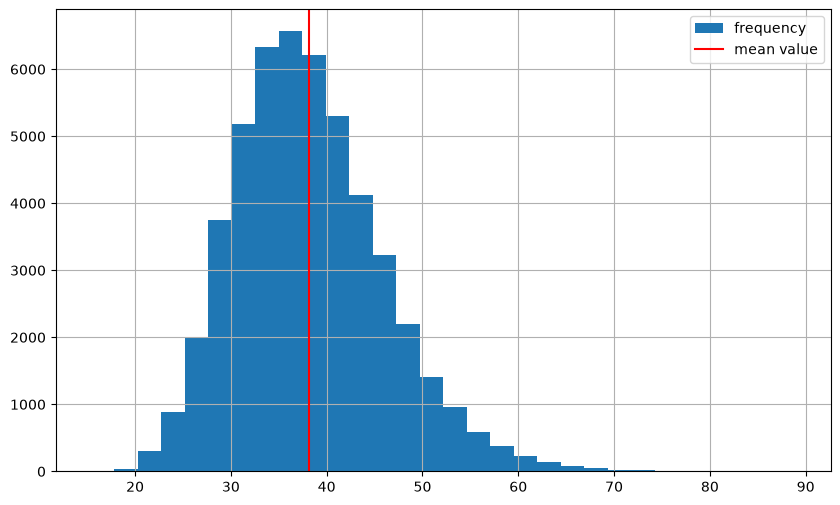

In [126]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1, 1, 1)

ax.hist(S[-1], bins=30, label='frequency')
ax.axvline(S[-1].mean(), color='r', label='mean value')

ax.grid(True)
ax.legend()

plt.show()

### 10.4.2 NumPy

In [127]:
def mcs_simulation_np(p):
    M, I = p
    dt = T / M
    S = np.zeros((M + 1, I))
    S[0] = S0
    rn = np.random.standard_normal(S.shape)
    for t in range(1, M + 1):
        S[t] = S[t-1] * np.exp((r - sigma ** 2 / 2) * dt + sigma * math.sqrt(dt) * rn[t])
    return S

In [128]:
%time S = mcs_simulation_np((M, I))

CPU times: user 64.7 ms, sys: 5.26 ms, total: 70 ms
Wall time: 69.1 ms


In [129]:
S[-1].mean()

np.float64(38.22040108622944)

In [130]:
%timeit S = mcs_simulation_np((M, I))

65 ms ± 305 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


### 10.4.3 Numba

In [131]:
mcs_simulation_nb = numba.jit(mcs_simulation_py)

In [132]:
%time S = mcs_simulation_nb((M, I))

CPU times: user 191 ms, sys: 7.57 ms, total: 198 ms
Wall time: 198 ms


In [133]:
%time S = mcs_simulation_nb((M, I))

CPU times: user 78.6 ms, sys: 1.96 ms, total: 80.5 ms
Wall time: 80.5 ms


In [134]:
S[-1].mean()

np.float64(38.20923423369955)

In [135]:
C0 = math.exp(-r * T) * np.maximum(K - S[-1], 0).mean()

In [136]:
C0

np.float64(3.8580015060338435)

In [137]:
%timeit S = mcs_simulation_nb((M, I))

84.6 ms ± 4.55 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### 10.4.4 Cython

In [138]:
%%cython
import numpy as np
cimport cython
from libc.math cimport exp, sqrt
cdef float S0 = 36.
cdef float T = 1.0
cdef float r = 0.06
cdef float sigma = 0.2
@cython.boundscheck(False)
@cython.wraparound(False)
def mcs_simulation_cy(p):
    cdef int M, I
    M, I = p
    cdef int t, i
    cdef float dt = T / M
    cdef double[:,:] S = np.zeros((M + 1, I))
    cdef double[:,:] rn = np.random.standard_normal((M + 1, I))
    S[0] = S0
    for t in range(1, M + 1):
        for i in range(I):
            S[t, i] = S[t-1, i] * exp((r - sigma ** 2 / 2) * dt + sigma * sqrt(dt) * rn[t, i])
    return np.array(S)

Content of stderr:
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib' ignored

In [139]:
%time S = mcs_simulation_cy((M, I))

CPU times: user 70.8 ms, sys: 8.46 ms, total: 79.2 ms
Wall time: 78.5 ms


In [140]:
S[-1].mean()

np.float64(38.22783526310754)

In [141]:
%timeit S = mcs_simulation_cy((M, I))

68.7 ms ± 695 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


### 10.4.5 멀티프로세싱

In [142]:
import multiprocessing as mp

In [143]:
pool = mp.get_context('fork').Pool(processes=4)

In [144]:
p = 20

In [145]:
%timeit S = np.hstack(pool.map(mcs_simulation_np, p * [(M, int(I / p))]))

26.4 ms ± 273 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [146]:
%timeit S = np.hstack(pool.map(mcs_simulation_nb, p * [(M, int(I / p))]))

30.9 ms ± 162 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [147]:
%timeit S = np.hstack(pool.map(mcs_simulation_cy, p * [(M, int(I / p))]))

27 ms ± 632 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [148]:
pool.close()

## 10.5 재귀적 pandas 알고리즘

**지수가중 이동평균(EWMA)**

- $\operatorname{EWMA}_0 = S_0$
- $\operatorname{EWMA}_t = \alpha \cdot S_t + \left( 1 - \alpha \right) \cdot \operatorname{EWMA}_{t-1} , t \in \left\{ 1, \dots, T \right\}$

### 10.5.1 파이썬

In [149]:
import pandas as pd

In [150]:
sym = 'SPY'

In [151]:
data = pd.DataFrame(pd.read_csv('../source/tr_eikon_eod_data.csv',
                                index_col=0, parse_dates=True)[sym]).dropna()

In [152]:
alpha = 0.25

In [153]:
data['EWMA'] = data[sym]

In [154]:
%%time
for t in zip(data.index, data.index[1:]):
    data.loc[t[1], 'EWMA'] = alpha * data.loc[t[1], sym] + (1 - alpha) * data.loc[t[0], 'EWMA']

CPU times: user 94 ms, sys: 1.78 ms, total: 95.8 ms
Wall time: 95.7 ms


In [155]:
data.head()

,SPY,EWMA
Date,,
2010-01-04,113.33,113.330000
2010-01-05,113.63,113.405000
2010-01-06,113.71,113.481250
2010-01-07,114.19,113.658438
2010-01-08,114.57,113.886328


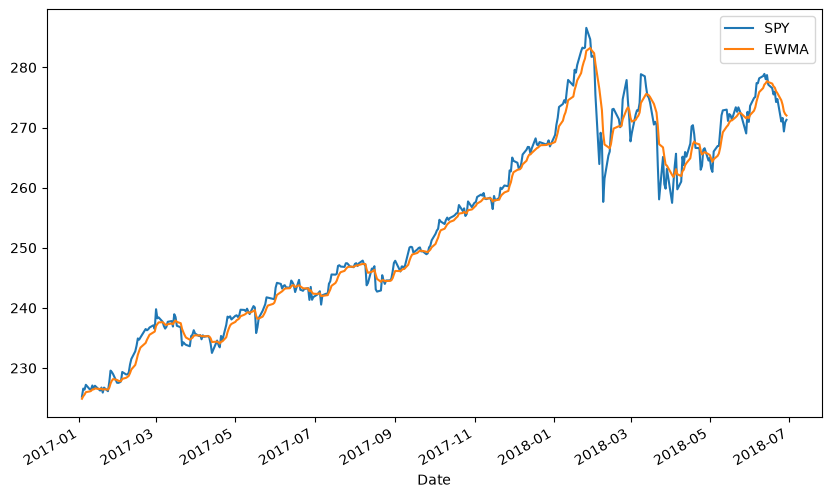

In [156]:
data[data.index > '2017-1-1'].plot(figsize=(10,6))
plt.show()

In [157]:
def ewma_py(x, alpha):
    y = np.zeros_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y

In [158]:
%time data['EWMA_PY'] = ewma_py(data[sym], alpha)

CPU times: user 95 μs, sys: 9 μs, total: 104 μs
Wall time: 98 μs


KeyError: 0

In [ ]:
%time data['EWMA_PY'] = ewma_py(data[sym].values, alpha)

CPU times: user 1.18 ms, sys: 17 μs, total: 1.19 ms
Wall time: 1.19 ms


### 10.5.2 Numba

In [ ]:
ewma_nb = numba.jit(ewma_py)

In [ ]:
%time data['EWMA_NB'] = ewma_nb(data[sym].values, alpha)

CPU times: user 161 ms, sys: 8.53 ms, total: 169 ms
Wall time: 169 ms


In [ ]:
%timeit data['EWMA_NB'] = ewma_nb(data[sym].values, alpha)

61.9 μs ± 1.45 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### 10.5.3 Cython

In [ ]:
%%cython
import numpy as np
cimport cython
@cython.boundscheck(False)
@cython.wraparound(False)
def ewma_cy(double[:] x, float alpha):
    cdef int i
    cdef double[:] y = np.empty_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return np.array(y)

In [ ]:
%time data['EWMA_CY'] = ewma_cy(data[sym].values, alpha)

CPU times: user 1.01 ms, sys: 686 μs, total: 1.7 ms
Wall time: 1.58 ms


In [ ]:
%timeit data['EWMA_CY'] = ewma_cy(data[sym].values, alpha)

68.4 μs ± 2.02 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
